# Significant MWU Venn diagrams

Four-set Venn diagrams for significant Dataset-TF pairs from the updated `MWU_merged.tsv` result files.

In [7]:
from collections import OrderedDict
from pathlib import Path
import os

CACHE_DIR = Path('.cache').resolve()
MPL_CACHE_DIR = CACHE_DIR / 'matplotlib'
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_DIR))
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from venn import venn

ALPHA_FDR = 0.1
SIGNIFICANT_COL = 'Significant_FDR_BH'

plt.rcParams.update(
    {
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'font.size': 18,
        'axes.titlesize': 16,
        'axes.titleweight': 'regular',
        'svg.fonttype': 'none',
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
    }
)


def find_results_dir() -> Path:
    candidates = [
        Path('results'),
        Path('reproduce/Reproduce scRNASeq Results/results'),
    ]

    for candidate in candidates:
        test_path = candidate / 'Methods_MWU-Delongs' / 'MWU' / 'MWU_merged.tsv'
        if test_path.exists():
            return candidate

    raise FileNotFoundError(
        'Could not find results directory. Run this notebook from the project root '
        'or from reproduce/Reproduce scRNASeq Results.'
    )


RESULTS_DIR = find_results_dir()
PLOT_DIR = RESULTS_DIR / 'venn_diagrams'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Reading MWU results from: {RESULTS_DIR.resolve()}')
print(f'Plots will be saved to: {PLOT_DIR.resolve()}')

Reading MWU results from: /Users/kisanthapa/Downloads/z-aggregate/reproduce/Reproduce scRNASeq Results/results
Plots will be saved to: /Users/kisanthapa/Downloads/z-aggregate/reproduce/Reproduce scRNASeq Results/results/venn_diagrams


In [8]:
def as_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(['true', '1', 'yes', 'y'])
    )


def mwu_merged_path(result_group: str) -> Path:
    path = RESULTS_DIR / f'{result_group}_MWU-Delongs' / 'MWU' / 'MWU_merged.tsv'
    if not path.exists():
        raise FileNotFoundError(f'MWU merged file not found: {path}')
    return path


def load_significant_pairs(
    result_group: str,
    group_col: str,
    order: list[str],
    label_map: dict[str, str],
    alpha: float = ALPHA_FDR,
) -> pd.DataFrame:
    path = mwu_merged_path(result_group)
    df = pd.read_csv(path, sep='\t')
    df.columns = df.columns.astype(str).str.strip()

    required = {'Dataset', 'TF', group_col, 'Adjusted_P_Value', SIGNIFICANT_COL}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f'{path} is missing required columns: {missing}')

    df = df[list(required)].copy()
    for col in ['Dataset', 'TF', group_col]:
        df[col] = df[col].astype('string').str.strip()
        df[col] = df[col].replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})

    df['Adjusted_P_Value'] = pd.to_numeric(df['Adjusted_P_Value'], errors='coerce')
    df = df.dropna(subset=['Dataset', 'TF', group_col, 'Adjusted_P_Value'])

    sig = df[
        as_bool(df[SIGNIFICANT_COL])
        & df['Adjusted_P_Value'].le(alpha)
        & df[group_col].isin(order)
    ].copy()

    sig['Dataset_TF'] = sig['Dataset'].astype(str) + ' | ' + sig['TF'].astype(str)
    sig['Group_Label'] = sig[group_col].astype(str).map(label_map).fillna(sig[group_col])

    print(
        f'{result_group}: {len(sig):,} significant rows '
        f'from {len(df):,} total rows at FDR <= {alpha}'
    )
    return sig.reset_index(drop=True)


def build_dataset_tf_sets(
    df: pd.DataFrame,
    group_col: str,
    order: list[str],
    label_map: dict[str, str],
) -> OrderedDict[str, set[str]]:
    sets = OrderedDict()
    for key in order:
        label = label_map.get(key, key)
        sets[label] = set(df.loc[df[group_col].eq(key), 'Dataset_TF'].dropna().astype(str))
    return sets


def summarize_sets(sets: OrderedDict[str, set[str]], title: str) -> tuple[pd.DataFrame, set[str]]:
    counts = pd.DataFrame(
        {
            'Set': list(sets.keys()),
            'Significant_Dataset_TF_Pairs': [len(values) for values in sets.values()],
        }
    )
    union = set.union(*sets.values()) if sets else set()
    shared = set.intersection(*sets.values()) if sets else set()

    print(f'{title}: {len(union):,} unique pairs; {len(shared):,} shared by all sets.')
    display(counts)
    return counts, shared


def plot_venn4(
    sets: OrderedDict[str, set[str]],
    title: str,
    output_name: str,
    colors: list[str],
) -> tuple[pd.DataFrame, set[str]]:
    counts, shared = summarize_sets(sets, title)

    fig, ax = plt.subplots(figsize=(9.5, 9.5), facecolor='white')
    venn(
        sets,
        cmap=colors,
        alpha=0.58,
        figsize=(9.5, 9.5),
        fontsize=18,
        legend_loc='upper right',
        ax=ax,
    )

    ax.set_title(title, pad=8)
    ax.set_facecolor('white')
    for text in ax.texts:
        text.set_color('#1F2933')
        text.set_fontweight('medium')
        text.set_fontsize(22)

    output_base = PLOT_DIR / output_name
    if output_base.suffix:
        output_base = output_base.with_suffix('')

    svg_path = output_base.with_suffix('.svg')
    fig.savefig(svg_path, bbox_inches='tight', pad_inches=0.1)
    plt.show()

    print(f'Saved: {svg_path}')
    return counts, shared

## Methods

Methods: 712 significant rows from 2,676 total rows at FDR <= 0.1
Significant Dataset-TF pairs by method
MWU test, BH FDR <= 0.1: 230 unique pairs; 129 shared by all sets.


,Set,Significant_Dataset_TF_Pairs
0,z-aggregate,184
1,viper,178
2,ulm,177
3,z-score,173


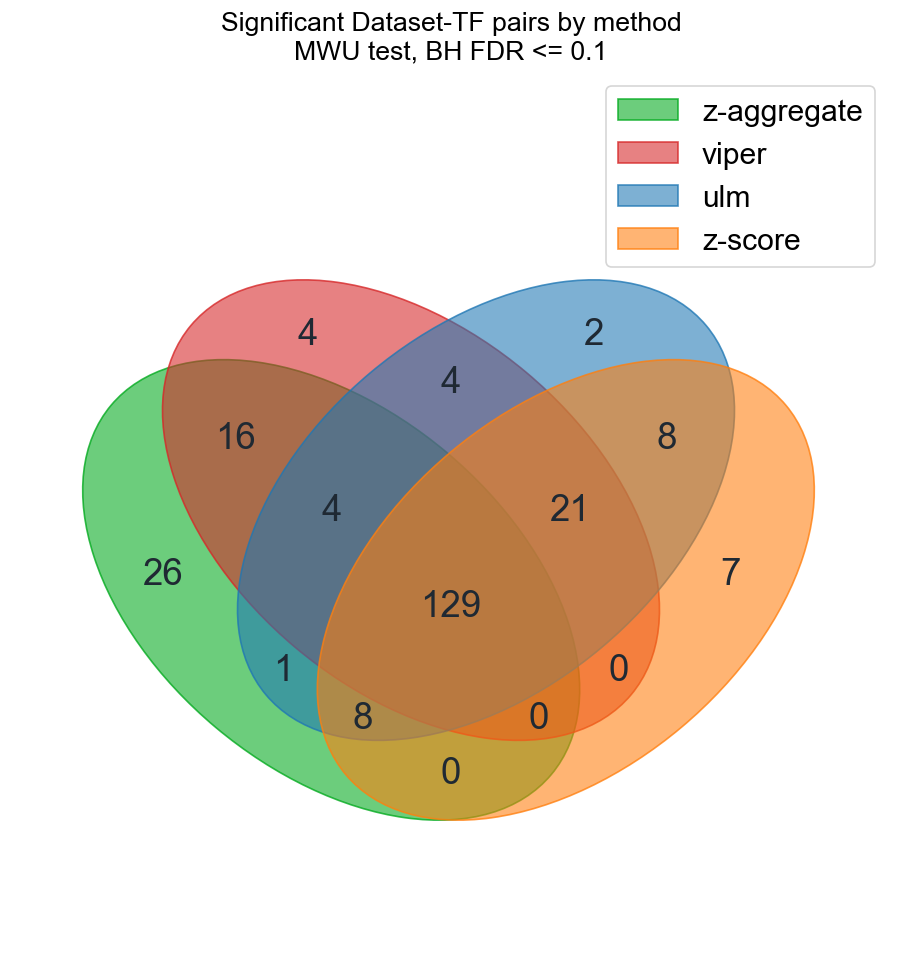

Saved: results/venn_diagrams/venn_methods_significant_dataset_tf_pairs.svg


In [9]:
METHOD_ORDER = ['z-agg', 'viper', 'ulm', 'zscore']
METHOD_LABELS = {
    'z-agg': 'z-aggregate',
    'viper': 'viper',
    'ulm': 'ulm',
    'zscore': 'z-score',
}
METHOD_COLORS = ["#02AA1E", "#D62728", "#1F77B4", "#FF7F0E"]

methods_sig = load_significant_pairs(
    result_group='Methods',
    group_col='Method',
    order=METHOD_ORDER,
    label_map=METHOD_LABELS,
)
method_sets = build_dataset_tf_sets(methods_sig, 'Method', METHOD_ORDER, METHOD_LABELS)
method_counts, method_shared = plot_venn4(
    method_sets,
    title=(
        'Significant Dataset-TF pairs by method\n'
        f'MWU test, BH FDR <= {ALPHA_FDR}'
    ),
    output_name='venn_methods_significant_dataset_tf_pairs',
    colors=METHOD_COLORS,
)

## Weights

Weights: 763 significant rows from 2,676 total rows at FDR <= 0.1
Significant Dataset-TF pairs by z-aggregate weight
MWU test, BH FDR <= 0.1: 266 unique pairs; 123 shared by all sets.


,Set,Significant_Dataset_TF_Pairs
0,uniform,184
1,correlation,191
2,specificity,188
3,nonzero rate,200


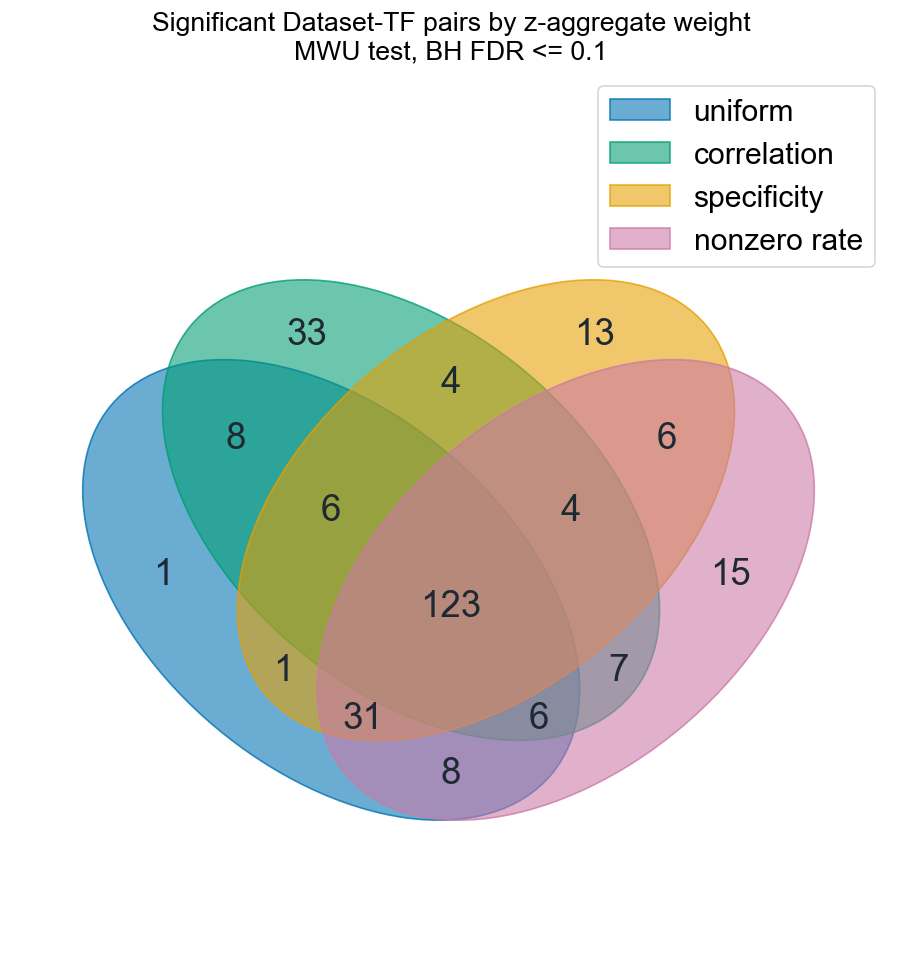

Saved: results/venn_diagrams/venn_weights_significant_dataset_tf_pairs.svg


In [10]:
WEIGHT_ORDER = ['UNIFORM', 'CORRELATION', 'SPECIFICITY', 'NONZERORATE']
WEIGHT_LABELS = {
    'UNIFORM': 'uniform',
    'CORRELATION': 'correlation',
    'SPECIFICITY': 'specificity',
    'NONZERORATE': 'nonzero rate',
}
WEIGHT_COLORS = ["#0072B2", "#009E73", "#E69F00", "#CC79A7"]

weights_sig = load_significant_pairs(
    result_group='Weights',
    group_col='Weight',
    order=WEIGHT_ORDER,
    label_map=WEIGHT_LABELS,
)
weight_sets = build_dataset_tf_sets(weights_sig, 'Weight', WEIGHT_ORDER, WEIGHT_LABELS)
weight_counts, weight_shared = plot_venn4(
    weight_sets,
    title=(
        'Significant Dataset-TF pairs by z-aggregate weight\n'
        f'MWU test, BH FDR <= {ALPHA_FDR}'
    ),
    output_name='venn_weights_significant_dataset_tf_pairs',
    colors=WEIGHT_COLORS,
)

## Priors

Priors: 631 significant rows from 3,305 total rows at FDR <= 0.1
Significant Dataset-TF pairs by prior
MWU test, BH FDR <= 0.1: 288 unique pairs; 39 shared by all sets.


,Set,Significant_Dataset_TF_Pairs
0,CausalPath,184
1,CollecTRI,123
2,DoRothEA,79
3,Ensemble,245


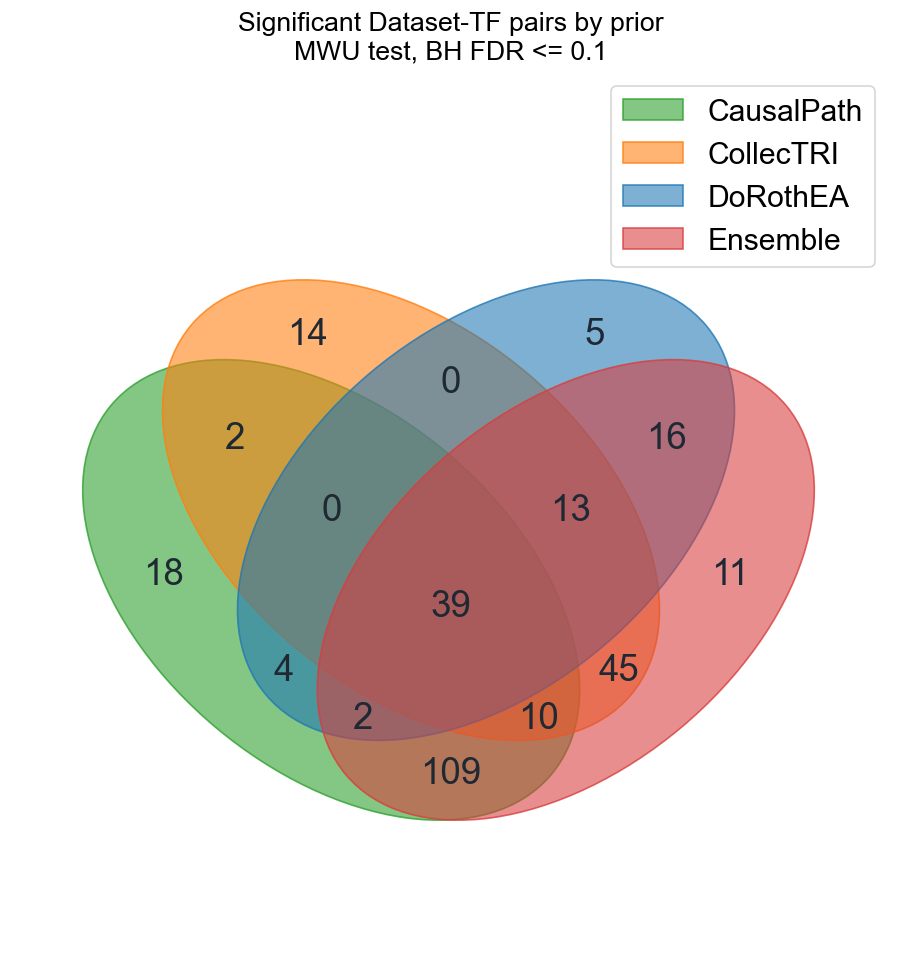

Saved: results/venn_diagrams/venn_priors_significant_dataset_tf_pairs.svg


In [11]:
PRIOR_ORDER = ['causalpath-priors', 'collectri', 'dorothea', 'ensemble-priors']
PRIOR_LABELS = {
    'causalpath-priors': 'CausalPath',
    'collectri': 'CollecTRI',
    'dorothea': 'DoRothEA',
    'ensemble-priors': 'Ensemble',
}
PRIOR_COLORS = ["#2CA02C", "#FF7F0E", "#1F77B4", "#D83D3D"]

priors_sig = load_significant_pairs(
    result_group='Priors',
    group_col='Prior',
    order=PRIOR_ORDER,
    label_map=PRIOR_LABELS,
)
prior_sets = build_dataset_tf_sets(priors_sig, 'Prior', PRIOR_ORDER, PRIOR_LABELS)
prior_counts, prior_shared = plot_venn4(
    prior_sets,
    title=(
        'Significant Dataset-TF pairs by prior\n'
        f'MWU test, BH FDR <= {ALPHA_FDR}'
    ),
    output_name='venn_priors_significant_dataset_tf_pairs',
    colors=PRIOR_COLORS,
)

## Priors Restricted To Common Significant TFs

22 TFs are significant in all four priors.


,Common_TF
0,AHR
1,ATF4
2,CEBPA
3,CEBPB
4,GABPA
5,HNF4A
6,IRF1
7,IRF9
8,MYB
9,MYBL2


Significant Dataset-TF pairs by prior
restricted to TFs significant in all four priors, BH FDR <= 0.1: 58 unique pairs; 39 shared by all sets.


,Set,Significant_Dataset_TF_Pairs
0,CausalPath,47
1,CollecTRI,49
2,DoRothEA,52
3,Ensemble,52


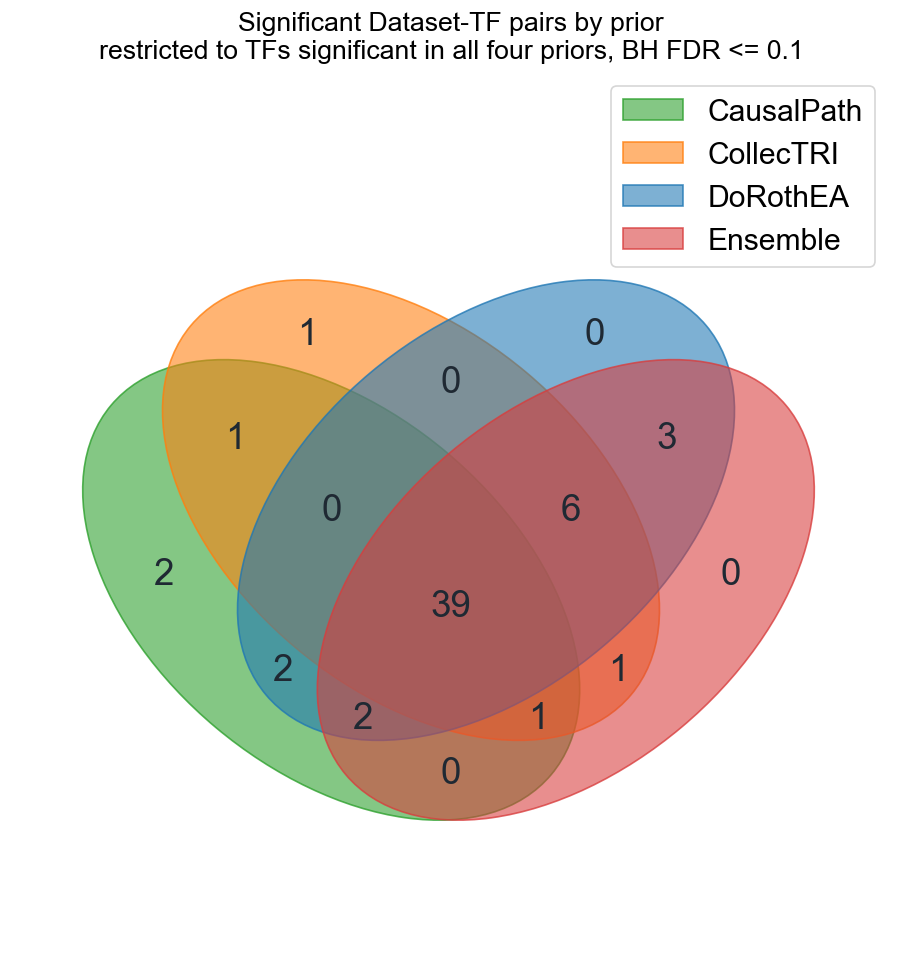

Saved: results/venn_diagrams/venn_priors_common_significant_tfs_dataset_tf_pairs.svg


In [12]:
prior_tf_sets = [
    set(priors_sig.loc[priors_sig['Prior'].eq(prior), 'TF'].dropna().astype(str))
    for prior in PRIOR_ORDER
]
common_prior_tfs = set.intersection(*prior_tf_sets)

print(f'{len(common_prior_tfs)} TFs are significant in all four priors.')
display(pd.DataFrame({'Common_TF': sorted(common_prior_tfs)}))

priors_common_tf_sig = priors_sig[priors_sig['TF'].astype(str).isin(common_prior_tfs)].copy()
prior_common_tf_sets = build_dataset_tf_sets(
    priors_common_tf_sig,
    group_col='Prior',
    order=PRIOR_ORDER,
    label_map=PRIOR_LABELS,
)
prior_common_tf_counts, prior_common_tf_shared = plot_venn4(
    prior_common_tf_sets,
    title=(
        'Significant Dataset-TF pairs by prior\n'
        f'restricted to TFs significant in all four priors, BH FDR <= {ALPHA_FDR}'
    ),
    output_name='venn_priors_common_significant_tfs_dataset_tf_pairs',
    colors=PRIOR_COLORS,
)